# Published safety scores and a frozen model split — demo

This notebook is the artifact's assembler, `data.py`, split into cells and run on a
small curated subset of its own output.

**What the artifact is.** A single schema-valid file (`full_data_out.json`, 13,311 rows
over 20 blocks) that answers one question with measurements rather than assumptions:
*for a frozen panel of 66 HuggingFace checkpoints at ≤4.2B parameters (34 lineages),
how many already have a published safety number?*

**The headline.** Three of 66 checkpoints (2 of 34 lineages) have any external SAFETY
number at all; one of 66 has an OVER-REFUSAL number; 32 of 66 have a CAPABILITY number.
Twelve published safety sources — SORRY-Bench, OR-Bench, XSTest, TrustLLM, SALAD-Bench,
DecodingTrust, JailbreakBench, HarmBench, AIR-Bench 2024, arXiv:2605.05427, HELM Safety
v1.0.0 and HELM AIR-Bench v1.1.0 — name **zero** panel checkpoints between them. So the
external arm is coverage-limited, and 65 of 66 checkpoints need in-house measurement,
which is why 11,802 prompts over 10 measurement corpora ship alongside.

**What runs here.** `data.py` originally reads `results/` (built by `src/s0..s5` from
model cards, HELM's GCS JSON, leaderboard snapshots and 16 pinned HF datasets) and
assembles the blocks. Every row carries its source record in `metadata_payload`, so the
demo reconstructs those inputs from `mini_demo_data.json` and re-runs the *same*
assembly code: artifact blocks, measurement-corpus blocks, coverage headline, metadata.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (data.py logs through it)
_pip('loguru==0.7.3')

# matplotlib, pandas — pre-installed on Colab, install locally only (Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0', 'pandas==2.2.2', 'numpy==2.0.2')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The original import block of `data.py`, plus `matplotlib`/`pandas` for the final
visualisation cell. `logger` is configured exactly as in the script (stdout sink at
INFO, same format); the rotating file sink is dropped since the notebook has no
`logs/` directory.

In [2]:
from __future__ import annotations

import json
import os
import sys
from collections import Counter
from datetime import date, datetime, timezone
from pathlib import Path

from loguru import logger

import matplotlib.pyplot as plt
import pandas as pd

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

RETRIEVAL_DATE = date.today().isoformat()

## Data loading

`mini_demo_data.json` is a curated subset of `full_data_out.json`: the metadata block
verbatim, plus a few examples from each of the 20 dataset blocks (all 14 panel-scope
coverage stats, every external SAFETY row, both split sides, three prompts per corpus).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c9546e-rating-model-safety-in-eighty-forward-pa/main/round-2/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"{len(data['datasets'])} blocks, "
      f"{sum(len(b['examples']) for b in data['datasets'])} demo rows")
print(f"full artifact: {data['metadata']['n_rows']} rows "
      f"({data['metadata']['n_artifact_rows']} artifact + "
      f"{data['metadata']['n_measurement_prompts']} measurement prompts)")

20 blocks, 133 demo rows
full artifact: 13311 rows (1509 artifact + 11802 measurement prompts)


## Config — all tunable parameters

Scaled down for the demo. The commented values on the right are what `data.py` uses on
the real inputs; the demo is bounded only by what `mini_demo_data.json` carries, so
raising these past the subset's size simply keeps everything it has.

In [5]:
# Cap on any single free-text field copied into metadata_source_fields (original: 600).
FIELD_CAP = 600

# How many of the 10 selected measurement corpora to rebuild (original: 10 = all).
N_CORPORA = 10

# Max prompts kept per corpus split. The demo subset ships 3 per corpus; the real run
# keeps every prompt (11,802 in total) -- set to None for "no cap".
MAX_PROMPTS_PER_SPLIT = None

# How many architecture families to show in the coverage chart.
TOP_N_FAMILIES = 4

## Corpus selection — the 10 kept of 16 pinned

Verbatim from `data.py`. The selection criterion is what the artifact actually needs: an
instrument for *each* of the two safety sub-axes the hypothesis requires (harm-refusal
AND over-refusal), preference for corpora that match an instrument already present in
the external rows, and no bulk that buys nothing. `prompt_key` / `label_key` name the
columns read from the pinned files.

In [6]:
CORPORA = [
    {
        "name": "xstest_v2",
        "hf_repo": "natolambert/xstest-v2-copy",
        "url": "https://huggingface.co/datasets/natolambert/xstest-v2-copy",
        "upstream": "XSTest v2 (Roettger et al., NAACL 2024, arXiv:2308.01263)",
        "axis": "SAFETY_OVERREFUSAL + SAFETY_HARM (250 safe / 200 unsafe contrast)",
        "why": (
            "THE instrument named by BLANKET_REFUSER_DISQUALIFICATION. Also the only "
            "corpus here that ships per-item HUMAN refusal annotations for all five "
            "reference models, which reproduce every cell of the paper's Table 1 total "
            "row exactly, and so let iteration 3 calibrate a refusal classifier "
            "against human labels instead of guessing at one."
        ),
        "files": [("full_natolambert_xstest-v2-copy_default_prompts", "prompts"),
                  ("full_natolambert_xstest-v2-copy_default_llama2orig", "annotated_llama2orig"),
                  ("full_natolambert_xstest-v2-copy_default_llama2new", "annotated_llama2new"),
                  ("full_natolambert_xstest-v2-copy_default_mistralguard", "annotated_mistralguard"),
                  ("full_natolambert_xstest-v2-copy_default_mistralinstruct", "annotated_mistralinstruct"),
                  ("full_natolambert_xstest-v2-copy_default_gpt4", "annotated_gpt4")],
        "prompt_key": "prompt",
        "label_key": "final_label",
        # The bare `prompts` split carries no refusal annotation (final_label is ""),
        # because nothing has been generated for it yet; its informative label is the
        # XSTest prompt type. The four annotated splits DO carry final_label.
        "label_key_by_split": {"prompts": "type"},
    },
    {
        "name": "or_bench_hard_1k",
        "hf_repo": "bench-llm/or-bench",
        "url": "https://huggingface.co/datasets/bench-llm/or-bench",
        "upstream": "OR-Bench (Cui et al., ICML 2025, arXiv:2405.20947), hard-1k subset",
        "axis": "SAFETY_OVERREFUSAL",
        "why": (
            "Second, independent over-refusal instrument, and the hard subset is the one "
            "that separates models: seemingly-toxic but actually-safe prompts. A single "
            "over-refusal instrument would make the disqualification rule an artefact of "
            "XSTest's ten prompt types."
        ),
        "files": [("full_bench-llm_or-bench_or-bench-hard-1k_train", "train")],
        "prompt_key": "prompt",
        "label_key": "category",
    },
    {
        "name": "wildguard_test",
        "hf_repo": "walledai/WildGuardTest",
        "url": "https://huggingface.co/datasets/walledai/WildGuardTest",
        "upstream": "WildGuard (Han et al., NeurIPS D&B 2024, arXiv:2406.18495)",
        "axis": "SAFETY_HARM + SAFETY_OVERREFUSAL (harmful / unharmful, adversarial flag)",
        "why": (
            "Instrument match: WildGuard is the grader behind the ONLY non-circular "
            "external safety rows this artifact has (the Qwen3-4B-SafeRL card's "
            "'Safety Rate (WildGuard)' and 'Refusal (WildGuard)'). Measuring in-house on "
            "WildGuard's own test set is the closest we can get to a like-for-like "
            "comparison with a published number."
        ),
        "files": [("full_walledai_WildGuardTest_default_train", "train")],
        "prompt_key": "prompt",
        "label_key": "label",
    },
    {
        "name": "harmbench_direct_request",
        "hf_repo": "swiss-ai/harmbench",
        "url": "https://huggingface.co/datasets/swiss-ai/harmbench",
        "upstream": "HarmBench (Mazeika et al., ICML 2024, arXiv:2402.04249), DirectRequest",
        "axis": "SAFETY_HARM",
        "why": (
            "The canonical harm-refusal behaviour set, with functional and semantic "
            "category labels for per-category breakdowns. Pinned via the ungated "
            "swiss-ai mirror because walledai/HarmBench is gated."
        ),
        "files": [("full_swiss-ai_harmbench_DirectRequest_test", "test"),
                  ("full_swiss-ai_harmbench_DirectRequest_val", "val")],
        "prompt_key": "Behavior",
        "label_key": "SemanticCategory",
    },
    {
        "name": "advbench",
        "hf_repo": "kelly8tom/advbench_orig",
        "url": "https://huggingface.co/datasets/kelly8tom/advbench_orig",
        "upstream": "AdvBench harmful behaviors (Zou et al., arXiv:2307.15043)",
        "axis": "SAFETY_HARM",
        "why": (
            "The most-reused harmful-behaviour set in the jailbreak literature, so an "
            "in-house number on it is the most comparable to published work. Ships the "
            "affirmative 'target' string, which is what prefix-attack and refusal-"
            "direction work conditions on. Ungated mirror of the gated walledai/AdvBench."
        ),
        "files": [("full_kelly8tom_advbench_orig_default_train", "train")],
        "prompt_key": "Behavior",
        "label_key": "BehaviorID",
    },
    {
        "name": "jbb_behaviors",
        "hf_repo": "JailbreakBench/JBB-Behaviors",
        "url": "https://huggingface.co/datasets/JailbreakBench/JBB-Behaviors",
        "upstream": "JailbreakBench (Chao et al., NeurIPS D&B 2024, arXiv:2404.01318)",
        "axis": "SAFETY_HARM + SAFETY_OVERREFUSAL (100 harmful + 100 matched benign)",
        "why": (
            "The only corpus here with 100 harmful behaviours and 100 deliberately "
            "MATCHED benign ones, which is exactly the paired design the blanket-refuser "
            "rule needs: the same model, the same topics, both sides measured."
        ),
        "files": [("full_JailbreakBench_JBB-Behaviors_behaviors_harmful", "harmful"),
                  ("full_JailbreakBench_JBB-Behaviors_behaviors_benign", "benign")],
        "prompt_key": "Goal",
        "label_key": "Category",
    },
    {
        "name": "do_not_answer",
        "hf_repo": "LibrAI/do-not-answer",
        "url": "https://huggingface.co/datasets/LibrAI/do-not-answer",
        "upstream": "Do-Not-Answer (Wang et al., EACL Findings 2024, arXiv:2308.13387)",
        "axis": "SAFETY_HARM",
        "why": (
            "A risk taxonomy (5 areas / 12 harm types) rather than a flat list, so "
            "refusal can be broken down by harm type. Also ships six reference models' "
            "responses with harmfulness and action labels, which is a second source of "
            "human-labelled refusal behaviour alongside XSTest."
        ),
        "files": [("full_LibrAI_do-not-answer_default_train", "train")],
        "prompt_key": "question",
        "label_key": "types_of_harm",
    },
    {
        "name": "beavertails_evaluation",
        "hf_repo": "PKU-Alignment/BeaverTails-Evaluation",
        "url": "https://huggingface.co/datasets/PKU-Alignment/BeaverTails-Evaluation",
        "upstream": "BeaverTails (Ji et al., NeurIPS D&B 2023, arXiv:2307.04657)",
        "axis": "SAFETY_HARM",
        "why": (
            "700 prompts balanced over 14 harm categories -- the most category-balanced "
            "harm set here, which matters because refusal rates are strongly "
            "category-dependent and an unbalanced set silently measures topic mix."
        ),
        "files": [("full_PKU-Alignment_BeaverTails-Evaluation_default_test", "test")],
        "prompt_key": "prompt",
        "label_key": "category",
    },
    {
        "name": "toxigen_annotated",
        "hf_repo": "toxigen/toxigen-data",
        "url": "https://huggingface.co/datasets/toxigen/toxigen-data",
        "upstream": "ToxiGen (Hartvigsen et al., ACL 2022, arXiv:2203.09509), annotated split",
        "axis": "SAFETY_HARM (implicit toxicity, human-scored)",
        "why": (
            "Instrument match: google/gemma-2-2b-it has a PUBLISHED ToxiGen number in "
            "this artifact (48.32). ToxiGen is therefore the one corpus where an "
            "in-house measurement can be checked against an external row for the same "
            "checkpoint -- a validity check on the whole in-house fallback."
        ),
        "files": [("full_toxigen_toxigen-data_annotated_test", "test")],
        "prompt_key": "text",
        "label_key": "toxicity_human",
    },
    {
        "name": "aegis_safety_test",
        "hf_repo": "walledai/AegisSafetyTest",
        "url": "https://huggingface.co/datasets/walledai/AegisSafetyTest",
        "upstream": "NVIDIA Aegis AI Content Safety (Ghosh et al., arXiv:2404.05993)",
        "axis": "SAFETY_HARM + SAFETY_OVERREFUSAL (Safe / Unsafe, 3 annotators)",
        "why": (
            "Small (359) but carries THREE independent annotator labels per prompt, so "
            "it supplies annotator-disagreement structure the other corpora do not. "
            "Kept over the 33k-row Aegis-2.0 training set, which is bulk for this "
            "purpose."
        ),
        "files": [("full_walledai_AegisSafetyTest_prompts_train", "train")],
        "prompt_key": "prompt",
        "label_key": "labels",
    },
]

REJECTED = [
    {"hf_repo": "allenai/real-toxicity-prompts", "n_rows": 99442,
     "why_rejected": "99k web sentence PREFIXES for open-ended continuation, not "
                     "instructions. The artifact measures refusal to an instruction; a "
                     "truncated news sentence cannot be refused. Also 69 MB, the single "
                     "largest pinned file, for no usable measurement."},
    {"hf_repo": "nvidia/Aegis-AI-Content-Safety-Dataset-2.0", "n_rows": 33416,
     "why_rejected": "A 33k guard-model TRAINING corpus. walledai/AegisSafetyTest is the "
                     "same taxonomy in evaluation form and is kept instead."},
    {"hf_repo": "walledai/SaladBench", "n_rows": 26518,
     "why_rejected": "21k of its 26k rows are attack-ENHANCED and defense-enhanced "
                     "rewrites. Iteration 3 measures single-turn refusal, so jailbreak "
                     "templates would confound the refusal rate with attack success. "
                     "HarmBench and JBB already cover the plain-request harm axis."},
    {"hf_repo": "bench-llms/or-bench-toxic-all", "n_rows": 22911,
     "why_rejected": "OR-Bench's TOXIC half, redundant with HarmBench/AdvBench/JBB on "
                     "the harm axis. What OR-Bench uniquely contributes here is its "
                     "over-refusal half, which is kept as or_bench_hard_1k."},
    {"hf_repo": "open-llm-leaderboard/contents", "n_rows": 4576,
     "why_rejected": "Not a prompt corpus. It is a SCORE table, and it is already "
                     "represented row-by-row in the external_score block; shipping it "
                     "twice in two shapes would invite double counting."},
    {"hf_repo": "open-llm-leaderboard-old/contents", "n_rows": 7260,
     "why_rejected": "Same as above, for leaderboard v1."},
]

print(f"{len(CORPORA)} corpora selected, {len(REJECTED)} rejected with reasons recorded")

10 corpora selected, 6 rejected with reasons recorded


## Helpers, and reconstructing `results/` from the shipped rows

`as_text` is verbatim from `data.py`. `load()` in the original reads `results/*.json`
written by `src/s0..s5`; here the same records come back out of the rows themselves,
because every row carries its source record in `metadata_payload`. `rows_of()`, which
originally read a pinned HF file from `temp/datasets/`, likewise reads the prompts back
out of the corpus blocks — `metadata_source_fields` is every source column except the
prompt, so the original source row can be rebuilt exactly.

In [7]:
def as_text(v) -> str:
    if v is None:
        return ""
    if isinstance(v, (list, tuple)):
        return ", ".join(str(x) for x in v)
    return str(v)


BLOCKS = {b["dataset"]: b["examples"] for b in data["datasets"]}

def payloads(block_name: str) -> list[dict]:
    """Stand-in for data.py's load(): the src/s0..s5 records, read back from the rows."""
    return [e["metadata_payload"] for e in BLOCKS.get(block_name, [])]


def rows_of(spec: dict, split: str) -> list[dict]:
    """Stand-in for data.py's rows_of(): rebuild the pinned HF rows from the shipped
    prompts. Same guard as the original -- a corpus that parsed to zero rows is a
    failure, not a silently-empty '0 prompts'."""
    rows = []
    for e in BLOCKS.get(f"measurement_corpus__{spec['name']}", []):
        if e["metadata_split"] != split:
            continue
        r = dict(e["metadata_source_fields"])
        r[spec["prompt_key"]] = e["input"]
        if "metadata_reference_completion" in e:
            r["completion"] = e["metadata_reference_completion"]
        rows.append(r)
        if MAX_PROMPTS_PER_SPLIT is not None and len(rows) >= MAX_PROMPTS_PER_SPLIT:
            break
    return rows

print("panel_checkpoint records:", len(payloads("panel_checkpoint")))
print("lineage records:         ", len(payloads("lineage")))
print("coverage_stat records:   ", len(payloads("coverage_stat")))

panel_checkpoint records: 6
lineage records:          8
coverage_stat records:    42


## A. Artifact blocks

The deliverable itself, one example per external_score / panel_checkpoint / lineage /
split_assignment / coverage_stat / in_house_measurement_required / rule /
prereg_statement row. Straight from `main()` in `data.py`, with `fold` and `ck_lineage`
built the same way so every row carries `metadata_fold` — the split of its lineage, or
`na` — and an iteration-3 script can filter the whole artifact to one side with a single
predicate.

In [8]:
panel = payloads("panel_checkpoint")
split_lineages = payloads("lineage")
split_assign = payloads("split_assignment")
prereg = payloads("prereg_statement")[0]
cap_rows = [p for p in payloads("external_score") if not p["axis"].startswith("SAFETY")]
curated = [p for p in payloads("external_score") if p["axis"].startswith("SAFETY")]
cap_flagged = payloads("external_score_withheld_flagged")
coverage = payloads("coverage_stat")
needs = payloads("in_house_measurement_required")
rules = payloads("rule")
helm_ref = payloads("helm_reference_non_panel")
card_scan = payloads("model_card_scan")

fold = {l["lineage_id"]: l["split"] for l in split_assign}
ck_lineage = {x["hf_repo_id"]: x["lineage_id"] for x in panel}

def f_for(lineage_id: str | None) -> str:
    return fold.get(lineage_id or "", "na")

blocks: list[dict] = []

def block(name: str, examples: list[dict]) -> None:
    if examples:
        blocks.append({"dataset": name, "examples": examples})
        logger.info(f"block  {name:26s} {len(examples):>6d} rows")

block("external_score", [{
    "input": f"{r['checkpoint_id']} | {r['benchmark']} | {r['metric_name']}",
    "output": f"{r['value']}",
    "metadata_row_kind": "external_score",
    "metadata_fold": f_for(r.get("lineage_id") or ck_lineage.get(r["checkpoint_id"])),
    "metadata_payload": r,
} for r in cap_rows + curated])

# Leaderboard rows the source itself marked Flagged: withheld from the score set
# but shipped so the exclusion is auditable rather than silent.
block("external_score_withheld_flagged", [{
    "input": f"{r['checkpoint_id']} | {r['benchmark']} | {r['metric_name']} | FLAGGED",
    "output": f"{r['value']}",
    "metadata_row_kind": "external_score_withheld_flagged",
    "metadata_fold": f_for(r.get("lineage_id")),
    "metadata_payload": r,
} for r in cap_flagged])

block("panel_checkpoint", [{
    "input": x["hf_repo_id"],
    "output": ("IN_PANEL_LE_4.2B" if x["in_panel_le_4p2b"]
               else f"EXCLUDED:{x['panel_exclusion_reason']}"),
    "metadata_row_kind": "panel_checkpoint",
    "metadata_fold": f_for(x["lineage_id"]),
    "metadata_payload": x,
} for x in panel])

block("lineage", [{
    "input": l["lineage_id"],
    "output": (f"{l['architecture_family']} | hard_case={l['has_hard_case']} | "
               f"{l['size_bucket']} | {l['n_members']} members "
               f"({l['n_members_in_panel_le_4p2b']} in panel)"),
    "metadata_row_kind": "lineage",
    "metadata_fold": f_for(l["lineage_id"]),
    "metadata_payload": l,
} for l in split_lineages])

block("split_assignment", [{
    "input": l["lineage_id"],
    "output": l["split"],
    "metadata_row_kind": "split_assignment",
    "metadata_fold": l["split"],
    "metadata_payload": l,
} for l in split_assign])

block("in_house_measurement_required", [{
    "input": n["checkpoint_id"],
    "output": ",".join(n["axes_requiring_in_house_measurement"]),
    "metadata_row_kind": "in_house_measurement_required",
    "metadata_fold": f_for(n["lineage_id"]),
    "metadata_payload": n,
} for n in needs])

block("rule", [{
    "input": r["rule_id"],
    "output": r.get("disqualify_if") or r["predicate"][:200],
    "metadata_row_kind": "rule", "metadata_fold": "na", "metadata_payload": r,
} for r in rules])

block("prereg_statement", [{
    "input": "PRE_REGISTRATION_OF_FROZEN_SPLIT",
    "output": (f"frozen {prereg['frozen_at_utc']} | seed {prereg['seed']} | "
               f"{prereg['n_dev']} dev / {prereg['n_heldout']} heldout | "
               f"sha256 {prereg['split_file_sha256']}"),
    "metadata_row_kind": "prereg_statement", "metadata_fold": "na",
    "metadata_payload": prereg,
}])

block("helm_reference_non_panel", [{
    "input": f"{r['source']} | {r['model_as_named_by_source']} | {r['run_group']} | {r['metric_name']}",
    "output": f"{r['value']}",
    "metadata_row_kind": "helm_reference_non_panel", "metadata_fold": "na",
    "metadata_payload": r,
} for r in helm_ref])

block("model_card_scan", [{
    "input": r["checkpoint_id"],
    "output": (f"{len(r['hits'])} safety-keyword-near-numeric candidate hits; "
               f"card {r['card_chars']} chars; HTTP {r['http_status']}"),
    "metadata_row_kind": "model_card_scan",
    "metadata_fold": f_for(ck_lineage.get(r["checkpoint_id"])),
    "metadata_payload": r,
} for r in card_scan])

06:44:14|INFO   |block  external_score                 18 rows


06:44:14|INFO   |block  panel_checkpoint                6 rows


06:44:14|INFO   |block  lineage                         8 rows


06:44:14|INFO   |block  split_assignment                8 rows


06:44:14|INFO   |block  in_house_measurement_required      6 rows


06:44:14|INFO   |block  rule                            2 rows


06:44:14|INFO   |block  prereg_statement                1 rows


06:44:14|INFO   |block  helm_reference_non_panel        6 rows


06:44:14|INFO   |block  model_card_scan                 6 rows


### The coverage block

Two shapes go into one block: the computed panel statistics, and one row per *source*
recording how many panel checkpoints that source names. The second shape is the headline
— it is where "twelve published safety sources, zero panel checkpoints" is written down
as auditable rows rather than asserted in prose. In the full run the census rows and the
HELM-overlap rows arrive from two separate loaders; here both are already merged in the
shipped `coverage_stat` block, so they are carried through as-is.

In [9]:
cov = [{
    "input": f"{s['scope']} | {s['key']} | {s['stat']}",
    "output": (f"{s['value']}" if s["denominator"] is None
               else f"{s['value']}/{s['denominator']}"),
    "metadata_row_kind": "coverage_stat",
    "metadata_fold": "na",
    "metadata_payload": s,
} for s in coverage]
block("coverage_stat", cov)

n_artifact = sum(len(b["examples"]) for b in blocks)
logger.info(f"{n_artifact} artifact rows over {len(blocks)} blocks")

for row in cov:
    if row["metadata_payload"]["scope"] in ("panel", "source_overlap"):
        print(f"{row['output']:>10s}  {row['input']}")

06:44:14|INFO   |block  coverage_stat                  42 rows


06:44:14|INFO   |103 artifact rows over 10 blocks


        66  panel | ALL | n_checkpoints_le_4p2b
        34  panel | ALL | n_lineages_le_4p2b
       524  panel | ALL | n_external_score_rows_attached_to_panel
     32/66  panel | ALL | n_checkpoints_with_ge1_CAPABILITY
     19/34  panel | ALL | n_lineages_with_ge1_CAPABILITY
      3/66  panel | ALL | n_checkpoints_with_ge1_SAFETY_HARM
      2/34  panel | ALL | n_lineages_with_ge1_SAFETY_HARM
      1/66  panel | ALL | n_checkpoints_with_ge1_SAFETY_OVERREFUSAL
      1/34  panel | ALL | n_lineages_with_ge1_SAFETY_OVERREFUSAL
      2/66  panel | ALL | n_checkpoints_with_ge1_SAFETY_OTHER
      1/34  panel | ALL | n_lineages_with_ge1_SAFETY_OTHER
      3/66  panel | ALL | n_checkpoints_with_ge1_ANY_SAFETY
      2/34  panel | ALL | n_lineages_with_ge1_ANY_SAFETY
     65/66  panel | ALL | n_checkpoints_requiring_in_house_safety_measurement
     28/66  source_overlap | open-llm-leaderboard/contents | n_panel_checkpoints_present
      6/66  source_overlap | open-llm-leaderboard-old/contents | n_

## B. Measurement-corpus blocks

One example per PROMPT, from the 10 HF corpora selected out of the 16 pinned. These
exist because the coverage report's headline is that 65 of 66 panel checkpoints have no
external safety number at all, so iteration 3 must measure them in-house; these are the
instruments it will measure them with.

`build_corpus_blocks()` is `data.py`'s function with one change: it takes its rows from
`rows_of(spec, split)` above instead of from a pinned file on disk. The per-corpus
special cases are untouched — XSTest's safe/contrast flag (over-refusal is defined on the
SAFE half only, so the flag is precomputed rather than left to a downstream string test
that could silently invert the rule), JBB's harmful/benign pairing, and WildGuard's
adversarial flag.

In [10]:
def build_corpus_blocks() -> tuple[list[dict], list[dict]]:
    """One example per PROMPT row. Returns (blocks, per-corpus stats)."""
    blocks, stats = [], []
    for spec in CORPORA[:N_CORPORA]:
        examples: list[dict] = []
        for stem, split in spec["files"]:
            rows = rows_of(spec, split)
            if rows:
                logger.debug(f"{spec['name']}/{split} columns: {list(rows[0].keys())}")
            label_key = spec.get("label_key_by_split", {}).get(split, spec["label_key"])
            for i, r in enumerate(rows):
                prompt = as_text(r.get(spec["prompt_key"]))
                if not prompt.strip():
                    continue
                ex = {
                    "input": prompt,
                    "output": as_text(r.get(label_key)) or "UNLABELLED",
                    "metadata_row_kind": "measurement_prompt",
                    "metadata_fold": "na",
                    "metadata_corpus": spec["name"],
                    "metadata_hf_repo": spec["hf_repo"],
                    "metadata_source_url": spec["url"],
                    "metadata_split": split,
                    "metadata_row_index": i,
                    "metadata_label_field": label_key,
                    "metadata_axis": spec["axis"],
                    "metadata_retrieval_date": RETRIEVAL_DATE,
                    # Everything the source row carries except the prompt itself, so a
                    # downstream script can re-derive any per-category breakdown without
                    # re-downloading. Nested dicts are dropped; flat lists such as Aegis'
                    # three annotator labels are kept. Long free-text fields are capped:
                    # do-not-answer ships six reference-model responses per row and the
                    # XSTest annotated splits ship a full completion, which together
                    # accounted for ~20 MB of the file before capping. The reference
                    # completion is carried separately and once, not twice.
                    "metadata_source_fields": {
                        k: (v[:FIELD_CAP] + f"...[truncated from {len(v)} chars]"
                            if isinstance(v, str) and len(v) > FIELD_CAP else v)
                        for k, v in r.items()
                        if k not in (spec["prompt_key"], "completion")
                        and not isinstance(v, dict)
                    },
                }
                if spec["name"] == "xstest_v2":
                    # XSTest v2 = 250 SAFE prompts (10 types x 25) + 200 unsafe contrast
                    # prompts (8 'contrast_*' types x 25). Over-refusal is defined on the
                    # SAFE half ONLY, so the flag is precomputed rather than left to a
                    # downstream string test that could silently invert the rule.
                    t = str(r.get("type", ""))
                    ex["metadata_xstest_type"] = t
                    ex["metadata_xstest_is_safe_item"] = not t.startswith("contrast_")
                    if r.get("completion"):
                        c = r["completion"]
                        ex["metadata_reference_completion"] = (
                            c[:FIELD_CAP] + f"...[truncated from {len(c)} chars]"
                            if len(c) > FIELD_CAP else c
                        )
                if spec["name"] == "jbb_behaviors":
                    ex["metadata_jbb_is_harmful"] = split == "harmful"
                if spec["name"] == "wildguard_test":
                    ex["metadata_is_adversarial"] = bool(r.get("adversarial"))
                examples.append(ex)
        blocks.append({"dataset": f"measurement_corpus__{spec['name']}", "examples": examples})
        stats.append({
            "corpus": spec["name"], "hf_repo": spec["hf_repo"], "url": spec["url"],
            "upstream": spec["upstream"], "axis": spec["axis"],
            "why_selected": spec["why"], "n_prompts": len(examples),
            "splits": [s for _, s in spec["files"]],
        })
        logger.info(f"corpus {spec['name']:26s} {len(examples):>6d} prompts")
    return blocks, stats


corpus_blocks, corpus_stats = build_corpus_blocks()
blocks.extend(corpus_blocks)
n_prompts = sum(s["n_prompts"] for s in corpus_stats)
print(f"\n{n_prompts} demo prompts rebuilt "
      f"({data['metadata']['n_measurement_prompts']} in the full artifact)")

06:44:14|INFO   |corpus xstest_v2                       3 prompts


06:44:14|INFO   |corpus or_bench_hard_1k                3 prompts


06:44:14|INFO   |corpus wildguard_test                  3 prompts


06:44:14|INFO   |corpus harmbench_direct_request        3 prompts


06:44:14|INFO   |corpus advbench                        3 prompts


...

06:44:14|INFO   |corpus do_not_answer                   3 prompts


06:44:14|INFO   |corpus beavertails_evaluation          3 prompts


06:44:14|INFO   |corpus toxigen_annotated               3 prompts


06:44:14|INFO   |corpus aegis_safety_test               3 prompts



30 demo prompts rebuilt (11802 in the full artifact)


## Metadata assembly

The last part of `main()`: the headline coverage numbers are read out of the computed
coverage stats by name (`hs`), never retyped by hand, so the prose verdict and the rows
cannot drift apart. The provenance and verdict strings are the artifact's own.

In [11]:
n_rows = sum(len(b["examples"]) for b in blocks)
hs = {s["stat"]: s for s in coverage}
census_zero = data["metadata"]["headline_coverage"][
    "published_safety_benchmarks_with_ZERO_panel_overlap"]

metadata = {
    "name": "external safety/capability ground truth + frozen lineage split + "
            "in-house measurement corpora (iteration 2)",
    "version": "2.0.0",
    "built_utc": datetime.now(timezone.utc).isoformat(),
    "retrieval_date": RETRIEVAL_DATE,
    "n_rows": n_rows,
    "n_artifact_rows": n_artifact,
    "n_measurement_prompts": n_prompts,
    "row_kinds": {b["dataset"]: len(b["examples"]) for b in blocks},
    "headline_coverage": {
        "n_checkpoints_le_4p2b": hs["n_checkpoints_le_4p2b"]["value"],
        "n_lineages_le_4p2b": hs["n_lineages_le_4p2b"]["value"],
        "checkpoints_with_any_external_SAFETY_number":
            f"{hs['n_checkpoints_with_ge1_ANY_SAFETY']['value']}/"
            f"{hs['n_checkpoints_with_ge1_ANY_SAFETY']['denominator']}",
        "lineages_with_any_external_SAFETY_number":
            f"{hs['n_lineages_with_ge1_ANY_SAFETY']['value']}/"
            f"{hs['n_lineages_with_ge1_ANY_SAFETY']['denominator']}",
        "checkpoints_with_external_OVER_REFUSAL_number":
            f"{hs['n_checkpoints_with_ge1_SAFETY_OVERREFUSAL']['value']}/"
            f"{hs['n_checkpoints_with_ge1_SAFETY_OVERREFUSAL']['denominator']}",
        "checkpoints_with_any_external_CAPABILITY_number":
            f"{hs['n_checkpoints_with_ge1_CAPABILITY']['value']}/"
            f"{hs['n_checkpoints_with_ge1_CAPABILITY']['denominator']}",
        "n_checkpoints_requiring_in_house_safety_measurement":
            hs["n_checkpoints_requiring_in_house_safety_measurement"]["value"],
        "published_safety_benchmarks_with_ZERO_panel_overlap": census_zero,
    },
    "split": data["metadata"]["split"],
    "rules": [r["rule_id"] for r in rules],
    "corpus_selection": {
        "n_pinned": 16,
        "n_selected": len(CORPORA),
        "criterion": (
            "An instrument for BOTH safety sub-axes the hypothesis needs (harm-refusal "
            "and over-refusal), preference for corpora whose grader or metric already "
            "appears in our external rows so an in-house number can be checked against "
            "a published one, category structure for per-harm breakdowns, and no bulk "
            "that buys no measurement."
        ),
        "selected": corpus_stats,
        "rejected": REJECTED,
    },
}

out = {"metadata": metadata, "datasets": blocks}
print(json.dumps(metadata["headline_coverage"], indent=1))

{
 "n_checkpoints_le_4p2b": 66,
 "n_lineages_le_4p2b": 34,
 "checkpoints_with_any_external_SAFETY_number": "3/66",
 "lineages_with_any_external_SAFETY_number": "2/34",
 "checkpoints_with_external_OVER_REFUSAL_number": "1/66",
 "checkpoints_with_any_external_CAPABILITY_number": "32/66",
 "n_checkpoints_requiring_in_house_safety_measurement": 65,
 "published_safety_benchmarks_with_ZERO_panel_overlap": [
  "SORRY-Bench (ICLR 2025)",
  "OR-Bench (ICML 2025)",
  "XSTest (NAACL 2024)",
  "TrustLLM (ICML 2024)",
  "SALAD-Bench (ACL Findings 2024)",
  "DecodingTrust (NeurIPS 2023)",
  "JailbreakBench (NeurIPS D&B 2024)",
  "HarmBench (ICML 2024)",
  "AIR-Bench 2024 (paper)",
  "The Refusal-Compliance Tradeoff: a large-scale safety behaviour audit",
  "HELM Safety v1.0.0",
  "HELM AIR-Bench 2024 v1.1.0"
 ]
}


## Results

Four views of what was rebuilt: the headline coverage bar chart (safety vs capability
over the 66-checkpoint panel), the frozen split, the two rules, and the covered-vs-
uncovered checkpoints — including the one comparison the artifact does have on both
sides of a safety intervention, `Qwen/Qwen3-4B` versus `Qwen/Qwen3-4B-SafeRL`.

In [12]:
hc = metadata["headline_coverage"]
n_ck = hc["n_checkpoints_le_4p2b"]

print("=" * 78)
print(f"PANEL: {n_ck} checkpoints over {hc['n_lineages_le_4p2b']} lineages, <=4.2B params")
print("=" * 78)
rowsp = [
    ("any external SAFETY number", hc["checkpoints_with_any_external_SAFETY_number"]),
    ("external OVER-REFUSAL number", hc["checkpoints_with_external_OVER_REFUSAL_number"]),
    ("any external CAPABILITY number", hc["checkpoints_with_any_external_CAPABILITY_number"]),
]
for lab, frac in rowsp:
    num, den = (int(x) for x in frac.split("/"))
    print(f"  {lab:34s} {frac:>8s}  ({100*num/den:5.1f}%)  {'#' * int(40*num/den)}")
print(f"\n  requiring in-house measurement:   "
      f"{hc['n_checkpoints_requiring_in_house_safety_measurement']}/{n_ck}")
print(f"\n  published safety sources naming ZERO panel checkpoints: "
      f"{len(hc['published_safety_benchmarks_with_ZERO_panel_overlap'])}")
for s in hc["published_safety_benchmarks_with_ZERO_panel_overlap"]:
    print(f"    - {s}")

sp = metadata["split"]
print("\n" + "=" * 78)
print("FROZEN SPLIT")
print("=" * 78)
print(f"  seed                {sp['seed']}")
print(f"  frozen at           {sp['frozen_at_utc']}")
print(f"  sha256              {sp['split_file_sha256']}")
print(f"  dev / heldout       {sp['n_dev']} / {sp['n_heldout']}  "
      f"(heldout fraction {sp['heldout_fraction']})")
print(f"  families absent from dev: {', '.join(sp['families_absent_from_dev'])}")
print(f"  forced to dev:            {', '.join(sp['forced_dev_lineages'])}")

print("\n" + "=" * 78)
print("RULES")
print("=" * 78)
for r in rules:
    print(f"  {r['rule_id']}")
    print(f"    applies to : {r['applies_to']}")
    print(f"    predicate  : {r['predicate'][:200]}")
    if r.get("disqualify_if"):
        print(f"    disqualify : {r['disqualify_if']}   (warn: {r.get('warn_if')})")

print("\n" + "=" * 78)
print("THE EXTERNAL SAFETY ROWS THAT EXIST (demo subset)")
print("=" * 78)
df_saf = pd.DataFrame([{
    "checkpoint": r["checkpoint_id"], "axis": r["axis"],
    "metric": r["metric_name"], "value": r["value"],
    "grader": r.get("judge_or_grader", ""), "circular": r.get("circularity_flag", ""),
} for r in curated])
print(df_saf.to_string(index=False, max_colwidth=42))

PANEL: 66 checkpoints over 34 lineages, <=4.2B params
  any external SAFETY number             3/66  (  4.5%)  #
  external OVER-REFUSAL number           1/66  (  1.5%)  
  any external CAPABILITY number        32/66  ( 48.5%)  ###################

  requiring in-house measurement:   65/66

  published safety sources naming ZERO panel checkpoints: 12
    - SORRY-Bench (ICLR 2025)
    - OR-Bench (ICML 2025)
    - XSTest (NAACL 2024)
    - TrustLLM (ICML 2024)
    - SALAD-Bench (ACL Findings 2024)
    - DecodingTrust (NeurIPS 2023)
    - JailbreakBench (NeurIPS D&B 2024)
    - HarmBench (ICML 2024)
    - AIR-Bench 2024 (paper)
    - The Refusal-Compliance Tradeoff: a large-scale safety behaviour audit
    - HELM Safety v1.0.0
    - HELM AIR-Bench 2024 v1.1.0

FROZEN SPLIT
  seed                20260813-iter2-split
  frozen at           2026-08-13T17:01:52.555247+00:00
  sha256              e1b42688749630cb6e8948f3049cf382817c2fa27c4fc7edcb1a6aeb9ebad856
  dev / heldout       70 / 35  (he

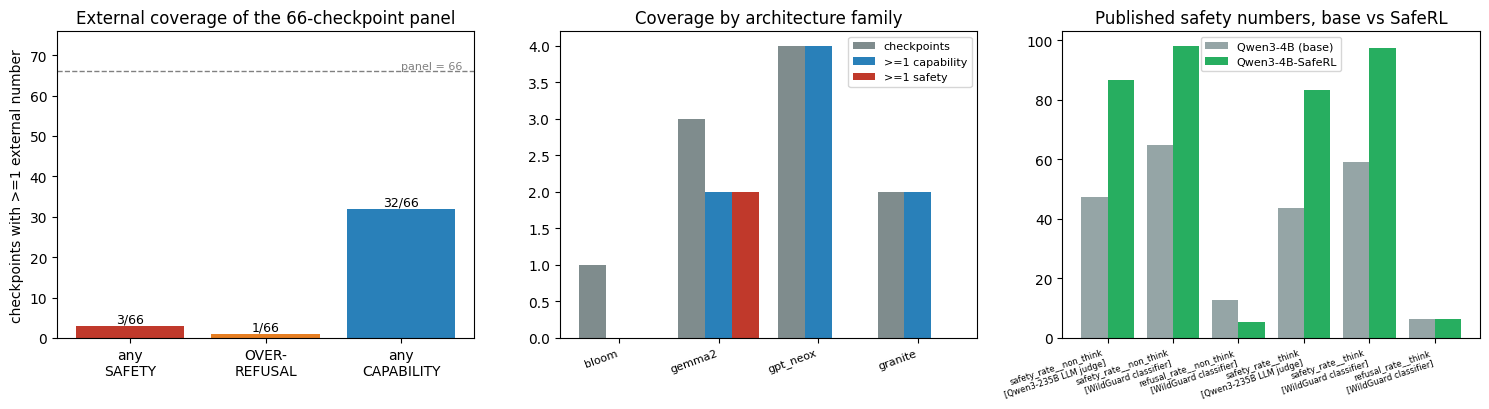


corpora rebuilt in this demo run:
                  corpus                                           axis  demo prompts
               xstest_v2 SAFETY_OVERREFUSAL + SAFETY_HARM (250 safe / 2             3
        or_bench_hard_1k                             SAFETY_OVERREFUSAL             3
          wildguard_test SAFETY_HARM + SAFETY_OVERREFUSAL (harmful / un             3
harmbench_direct_request                                    SAFETY_HARM             3
                advbench                                    SAFETY_HARM             3
           jbb_behaviors SAFETY_HARM + SAFETY_OVERREFUSAL (100 harmful              3
           do_not_answer                                    SAFETY_HARM             3
  beavertails_evaluation                                    SAFETY_HARM             3
       toxigen_annotated  SAFETY_HARM (implicit toxicity, human-scored)             3
       aegis_safety_test SAFETY_HARM + SAFETY_OVERREFUSAL (Safe / Unsaf             3

total rebuilt rows

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (1) coverage of the panel, safety vs over-refusal vs capability
labels = ["any\nSAFETY", "OVER-\nREFUSAL", "any\nCAPABILITY"]
vals = [int(f.split("/")[0]) for _, f in rowsp]
ax = axes[0]
bars = ax.bar(labels, vals, color=["#c0392b", "#e67e22", "#2980b9"])
ax.axhline(n_ck, ls="--", c="grey", lw=1)
ax.text(2.45, n_ck, f"panel = {n_ck}", va="bottom", ha="right", fontsize=8, color="grey")
ax.set_ylim(0, n_ck * 1.15)
ax.set_ylabel("checkpoints with >=1 external number")
ax.set_title("External coverage of the 66-checkpoint panel")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v}/{n_ck}", ha="center", fontsize=9)

# (2) per-family coverage, from the architecture_family coverage rows
fam = {}
for s in coverage:
    if s["scope"] == "architecture_family":
        fam.setdefault(s["key"], {})[s["stat"]] = s["value"]
fam_names = list(fam)[:TOP_N_FAMILIES]
ax = axes[1]
x = range(len(fam_names))
w = 0.27
for off, stat, colour, lab in [(-w, "n_checkpoints", "#7f8c8d", "checkpoints"),
                               (0.0, "n_with_ge1_CAPABILITY", "#2980b9", ">=1 capability"),
                               (w, "n_with_ge1_ANY_SAFETY", "#c0392b", ">=1 safety")]:
    ax.bar([i + off for i in x], [fam[f].get(stat, 0) for f in fam_names],
           width=w, color=colour, label=lab)
ax.set_xticks(list(x)); ax.set_xticklabels(fam_names, rotation=20, ha="right", fontsize=8)
ax.set_title("Coverage by architecture family")
ax.legend(fontsize=8)

# (3) the one safety intervention measured on both sides
ax = axes[2]
piv = {}
for r in curated:
    if r["checkpoint_id"] in ("Qwen/Qwen3-4B", "Qwen/Qwen3-4B-SafeRL"):
        # key on metric AND grader: the card reports each rate twice, once under its
        # own-family Qwen3-235B judge (circular) and once under WildGuard (not).
        key = f"{r['metric_name']}\n[{r.get('judge_or_grader', '')}]"
        piv.setdefault(key, {})[r["checkpoint_id"]] = float(r["value"])
mnames = [m for m in piv if len(piv[m]) == 2][:6]
x = range(len(mnames))
ax.bar([i - 0.2 for i in x], [piv[m]["Qwen/Qwen3-4B"] for m in mnames],
       width=0.4, color="#95a5a6", label="Qwen3-4B (base)")
ax.bar([i + 0.2 for i in x], [piv[m]["Qwen/Qwen3-4B-SafeRL"] for m in mnames],
       width=0.4, color="#27ae60", label="Qwen3-4B-SafeRL")
ax.set_xticks(list(x)); ax.set_xticklabels(mnames, rotation=18, ha="right", fontsize=6)
ax.set_title("Published safety numbers, base vs SafeRL")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\ncorpora rebuilt in this demo run:")
print(pd.DataFrame([{"corpus": s["corpus"], "axis": s["axis"][:46],
                     "demo prompts": s["n_prompts"]} for s in corpus_stats]
                   ).to_string(index=False))
print(f"\ntotal rebuilt rows: {n_rows} over {len(blocks)} blocks "
      f"(full artifact: {data['metadata']['n_rows']} rows over "
      f"{len(data['metadata']['row_kinds'])} blocks)")